# Sentiment Analysis

In [79]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
# import CSV file
df = pd.read_csv('/content/Twitter_Data.csv')
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [81]:
df.tail()

,clean_text,category
162975,why these 456 crores paid neerav modi not reco...,-1.0
162976,dear rss terrorist payal gawar what about modi...,-1.0
162977,did you cover her interaction forum where she ...,0.0
162978,there big project came into india modi dream p...,0.0
162979,have you ever listen about like gurukul where ...,1.0


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [83]:
df.describe()

,category
count,162973.000000
mean,0.225436
std,0.781279
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [84]:
# missing values
df.isnull().sum()

,0
clean_text,4
category,7


In [85]:
# To clear the missing values
df=df.dropna(subset=['clean_text','category'])

In [86]:
df.isnull().sum()

,0
clean_text,0
category,0


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162969 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162969 non-null  object 
 1   category    162969 non-null  float64
dtypes: float64(1), object(1)
memory usage: 3.7+ MB


In [88]:
df.duplicated().sum()

np.int64(0)

In [89]:
df['category'].value_counts()

,count
category,
1.0,72249
0.0,55211
-1.0,35509


In [90]:
# Changing float into integer
df['category']=df['category'].astype('int')

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 162969 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   clean_text  162969 non-null  object
 1   category    162969 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.7+ MB


In [92]:
df['category'].value_counts()

,count
category,
1,72249
0,55211
-1,35509


<Axes: xlabel='category', ylabel='count'>

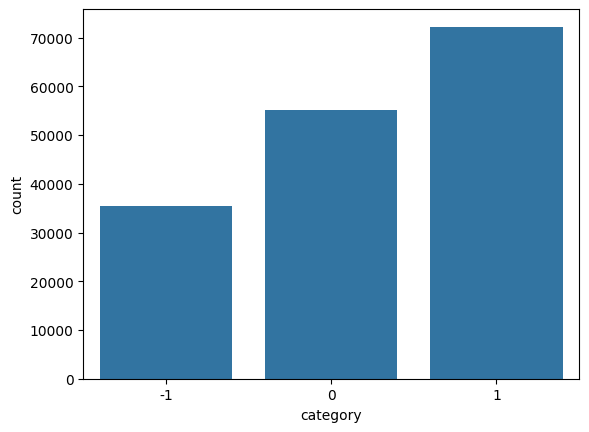

In [93]:
# data visualization
sns.countplot(x='category',data=df)

In [94]:
df['clean_text'].head(5)

,clean_text
0,when modi promised “minimum government maximum...
1,talk all the nonsense and continue all the dra...
2,what did just say vote for modi welcome bjp t...
3,asking his supporters prefix chowkidar their n...
4,answer who among these the most powerful world...


In [95]:
df['clean_text'].tail(5)

,clean_text
162975,why these 456 crores paid neerav modi not reco...
162976,dear rss terrorist payal gawar what about modi...
162977,did you cover her interaction forum where she ...
162978,there big project came into india modi dream p...
162979,have you ever listen about like gurukul where ...


In [96]:
# text preprocessing
# lower case
df['clean_text']=df['clean_text'].str.lower()

In [97]:
# remove punctuations and extra spaces
import re
def preprocess(text):
    text = text.lower()

    contractions = {
        "don't": "do not",
        "didn't": "did not",
        "can't": "can not",
        "won't": "will not",
        "isn't": "is not",
        "aren't": "are not",
        "wasn't": "was not",
        "weren't": "were not",
        "couldn't": "could not",
        "shouldn't": "should not",
        "wouldn't": "would not"
    }

    for key, value in contractions.items():
        text = text.replace(key, value)

    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [98]:
df['clean_text'] = df['clean_text'].apply(preprocess)

In [99]:
df['clean_text'].head(5)

,clean_text
0,when modi promised minimum government maximum ...
1,talk all the nonsense and continue all the dra...
2,what did just say vote for modi welcome bjp to...
3,asking his supporters prefix chowkidar their n...
4,answer who among these the most powerful world...


In [100]:
df['category'].value_counts(normalize=True) * 100

,proportion
category,
1,44.332971
0,33.878222
-1,21.788806


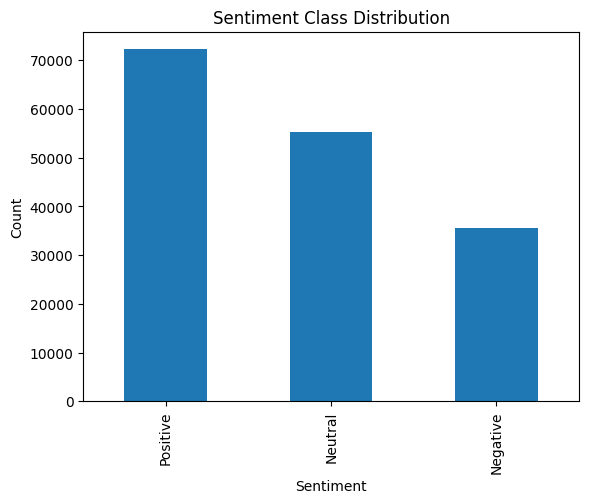

In [101]:
# Class distribution using bar chart
counts = df['category'].map({
    -1: 'Negative',
     0: 'Neutral',
     1: 'Positive'
}).value_counts()

counts.plot(kind='bar')

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [102]:
# Seperating X and y
X=df['clean_text']
y=df['category']

In [103]:
# Train, test and split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [104]:
# Vectorization using Tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf=tfidf.fit_transform(X_train)
X_test_tfidf=tfidf.transform(X_test)


In [105]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(130375, 5000)
(32594, 5000)


In [106]:
# Training models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
models={
    'Logistic Regression':LogisticRegression(max_iter=1000,random_state=42),
    'Naive Bayes':MultinomialNB(),
    'Support Vector Machine':LinearSVC(random_state=42),
}
for name,model in models.items():
  model.fit(X_train_tfidf,y_train)
  y_pred=model.predict(X_test_tfidf)
  accuracy=accuracy_score(y_test,y_pred)
  print(f'{name} Accuracy: {accuracy:.4f}')
  print(classification_report(y_test,y_pred))
  print(confusion_matrix(y_test,y_pred))

Logistic Regression Accuracy: 0.9149
              precision    recall  f1-score   support

          -1       0.91      0.80      0.85      7102
           0       0.90      0.98      0.93     11042
           1       0.93      0.92      0.93     14450

    accuracy                           0.91     32594
   macro avg       0.91      0.90      0.90     32594
weighted avg       0.92      0.91      0.91     32594

[[ 5668   656   778]
 [   92 10786   164]
 [  485   599 13366]]
Naive Bayes Accuracy: 0.7572
              precision    recall  f1-score   support

          -1       0.87      0.47      0.61      7102
           0       0.84      0.72      0.78     11042
           1       0.69      0.93      0.79     14450

    accuracy                           0.76     32594
   macro avg       0.80      0.71      0.73     32594
weighted avg       0.78      0.76      0.75     32594

[[ 3316   775  3011]
 [  140  7980  2922]
 [  361   705 13384]]
Support Vector Machine Accuracy: 0.9266
    

In [107]:
# Hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
param_grid={
    'C':[0.1,1,10]
}
grid_search=GridSearchCV(LinearSVC(random_state=42,max_iter=5000),param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)
grid_search.fit(X_train_tfidf,y_train)
print(f'Best Parameters:{grid_search.best_params_}')
print(f'Best Score:{grid_search.best_score_}')

Best Parameters:{'C': 10}
Best Score:0.9246558005752638


In [108]:
# Evaluating the best model
best_model=grid_search.best_estimator_
y_pred=best_model.predict(X_test_tfidf)
accuracy=accuracy_score(y_test,y_pred)
print(f'Test Accuracy:{accuracy:.4f}')
print("classification report:\n",classification_report(y_test,y_pred))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))

Test Accuracy:0.9278
classification report:
               precision    recall  f1-score   support

          -1       0.91      0.84      0.87      7102
           0       0.91      0.98      0.94     11042
           1       0.95      0.93      0.94     14450

    accuracy                           0.93     32594
   macro avg       0.92      0.92      0.92     32594
weighted avg       0.93      0.93      0.93     32594

confusion matrix:
 [[ 5954   531   617]
 [  104 10813   125]
 [  458   518 13474]]


In [109]:
import joblib

joblib.dump(best_model, "sentiment_analysis_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [110]:
sample = "I didn't like this movie"

processed = preprocess(sample)

print(processed)

vector = tfidf.transform([processed])

prediction = best_model.predict(vector)

print(prediction)

i did not like this movie
[0]


In [111]:
df[df['clean_text'].str.contains("did not like", case=False, na=False)]

,clean_text,category
11748,abolition was one the agenda modi 2014 electio...,1
46142,many people who did not like the news coming f...,1
66554,manmohan singh was internally unhappy with son...,-1
69378,soniaji was right about fascist modi destroyed...,-1
96050,2014 they did not like modi but 2019 they are ...,1
101764,yes yes yes did not like him did not know anyt...,0


In [112]:
samples = [
    "I like this movie",
    "I did not like this movie",
    "I didn't like this movie",
    "I hate this movie",
    "This movie is not good",
    "This movie is bad"
]

for s in samples:
    p = preprocess(s)
    pred = best_model.predict(tfidf.transform([p]))[0]
    print(f"Original: {s}")
    print(f"Processed: {p}")
    print(f"Prediction: {pred}")
    print("-"*50)

Original: I like this movie
Processed: i like this movie
Prediction: 0
--------------------------------------------------
Original: I did not like this movie
Processed: i did not like this movie
Prediction: 0
--------------------------------------------------
Original: I didn't like this movie
Processed: i did not like this movie
Prediction: 0
--------------------------------------------------
Original: I hate this movie
Processed: i hate this movie
Prediction: -1
--------------------------------------------------
Original: This movie is not good
Processed: this movie is not good
Prediction: -1
--------------------------------------------------
Original: This movie is bad
Processed: this movie is bad
Prediction: -1
--------------------------------------------------


In [113]:
sample = "I like this movie"

processed = preprocess(sample)

print(processed)

vector = tfidf.transform([processed])

print(best_model.predict(vector))

i like this movie
[0]
